#Предобработка и анализ данных для классификации доходов на датасете Adult (Census Income)

Objectives: выполняет начальную загрузку, очистку и предварительный анализ датасета Adult, предназначенного для задачи бинарной классификации. Цель — определить, превышает ли годовой доход человека 50 тысяч долларов на основе демографических, социальных и экономических признаков.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']

df = pd.read_csv(url, names=columns, sep=',\s', engine='python')

df.replace('?', np.nan, inplace=True)

print("--- Размер датасета ---")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

print("\n--- Типы данных и пропуски ---")
df.info()

duplicates = df.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Дубликаты удалены.")

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-712154604.py:19: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, names=columns, sep=',\s', engine='python')


--- Размер датасета ---
Строк: 32561, Столбцов: 15

--- Типы данных и пропуски ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

Количеств

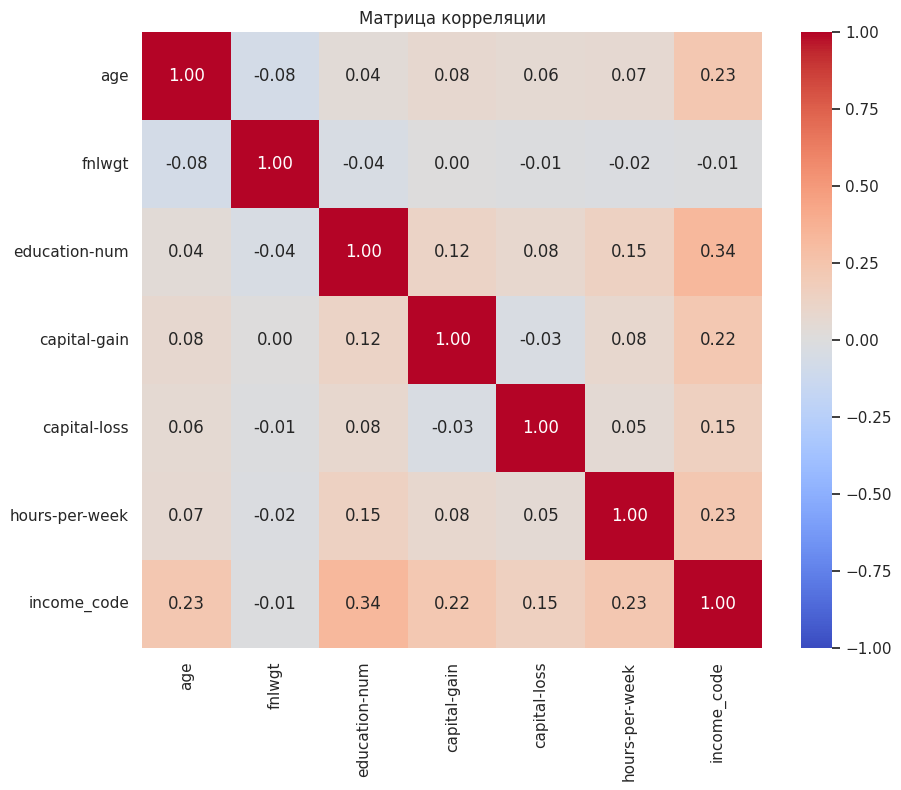

In [2]:
df['income_code'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляции')
plt.show()

df.drop('income_code', axis=1, inplace=True)

In [3]:
print("Пропуски до обработки:\n", df.isnull().sum()[df.isnull().sum() > 0])

df['native-country'] = df['native-country'].fillna('Other')

imputer_mode = SimpleImputer(strategy='most_frequent')
df['workclass'] = imputer_mode.fit_transform(df[['workclass']]).ravel()

df['occupation'] = df['occupation'].fillna(method='ffill')

print("\nПропуски после обработки:\n", df.isnull().sum().sum())

Пропуски до обработки:
 workclass         1836
occupation        1843
native-country     582
dtype: int64

Пропуски после обработки:
 0


/tmp/ipython-input-3501534225.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['occupation'] = df['occupation'].fillna(method='ffill')


In [4]:
cat_columns = df.select_dtypes(include=['object']).columns
print(f"Категориальные колонки: {list(cat_columns)}")

le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])

freq_encoding = df['native-country'].value_counts() / len(df)
df['native-country_freq'] = df['native-country'].map(freq_encoding)

df.drop('native-country', axis=1, inplace=True)

df = pd.get_dummies(df, columns=['workclass', 'education', 'marital-status',
                                 'occupation', 'relationship', 'race', 'sex'],
                    drop_first=True)

print("Размер после кодирования:", df.shape)

Категориальные колонки: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
Размер после кодирования: (32537, 59)


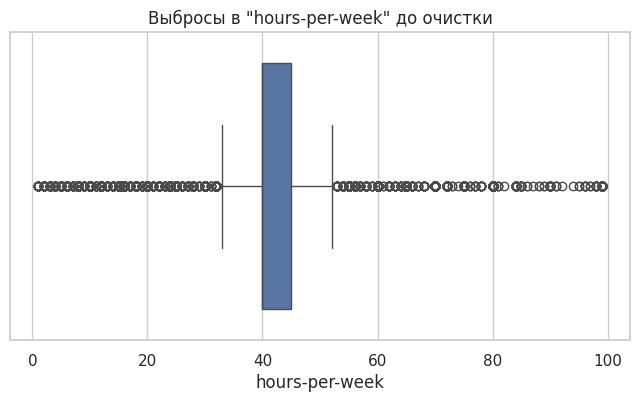

Удалено строк с выбросами: 440


In [5]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['hours-per-week'])
plt.title('Выбросы в "hours-per-week" до очистки')
plt.show()

from scipy import stats
z_scores = np.abs(stats.zscore(df['hours-per-week']))

df_clean = df[(z_scores < 3)]

print(f"Удалено строк с выбросами: {df.shape[0] - df_clean.shape[0]}")
df = df_clean

Файл сохранен.


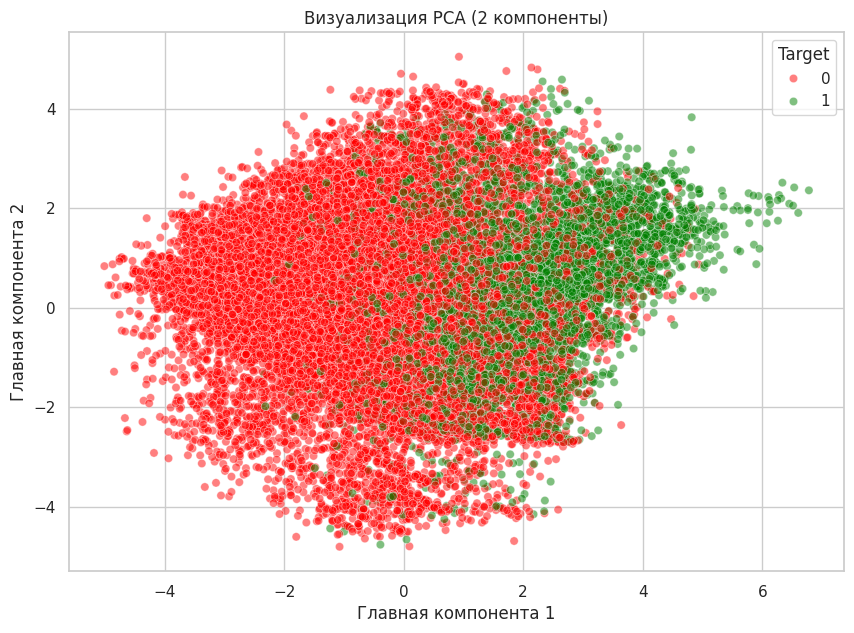

Объясненная дисперсия: [0.05990141 0.0445576 ]
Суммарная потеря информации: 89.55%


In [6]:
df.to_csv('processed_adult_data.csv', index=False)
print("Файл сохранен.")

X = df.drop('income', axis=1)
y = df['income']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = y.values

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="PC1", y="PC2",
    hue="Target",
    palette=["red", "green"],
    data=pca_df,
    alpha=0.5
)
plt.title('Визуализация PCA (2 компоненты)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.show()

print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")
print(f"Суммарная потеря информации: {1 - sum(pca.explained_variance_ratio_):.2%}")

#Conclusion

Preprocessing: Исходный датасет содержал категориальные признаки и пропуски. Мы применили OneHotEncoding (что сильно увеличило количество столбцов) и Frequency Encoding для стран. Размерность данных выросла, что делает их сложными для прямой визуализации.

Emissions: Анализ hours-per-week показал наличие людей, работающих аномально много (или мало). Z-оценка позволила отфильтровать экстремальные значения, сделав распределение более нормальным.

PCA (Сжатие):

- Мы сжали десятки столбцов до 2-х главных компонент.

- На графике рассеивания (Scatterplot) можно заметить, разделяются ли классы (доход >50K и <=50K).

- Если классы сильно смешаны (точки красного и зеленого цвета в одной куче), это значит, что в 2D пространстве линейно разделить их сложно, и для модели потребуется больше признаков или нелинейные методы.

- Обычно первые 2 компоненты объясняют около 15-30% дисперсии в таких сложных соц-дем данных.